In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor
import matplotlib.pyplot as plt

from own_implementation import BPTF as BPTF
import bptf

# Please run everything up to the first bptf fit
# Thereafter, run each following cell on their own

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Theta_DK_M = [torch.tensor(factor) for factor in Theta_DK_M]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Load data

In [3]:
use_existing_data = True

# for the first bptf.fit:
# using seed 100 causes the assert delta >= 0 to trip
# but using seed 0 doesn't
# please swap between the 2 seeds to get the 2 different types of assertion errors in the other cells
rn.seed(100)
device = 'cuda'

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :24, :]
    data = torch.tensor(data.todense(), dtype=torch.float64, device=device)
else:
    data = generate(shp=(200, 200, 20, 24, 3), K=10)[1]
    data = torch.tensor(data, dtype=torch.float64, device=device)

# Building mask (base example)

In [4]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

# Fit model

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-5841796102.986349, 12455612.740704235, 12780599.95472699, 13796962.434654461, 15837751.015097693, 18037439.020309098, 20236331.496869538, 22032213.325766753, 23225865.249990936, 24007075.187137753, 24558551.128460336, 24953147.11881072, 25238578.444170803, 25452363.201376155, 25618738.73198487, 25751453.468794283, 25860132.890382513, 25953083.45095992, 26037001.661655657, 26117668.496822953, 26203011.072693843, 26290342.742493417, 26353347.121731788, 26398548.427546773, 26436402.08763027, 26470168.642829593, 26500947.436190993, 26529128.026536487, 26554835.62899608, 26578179.034875844, 26599373.89131646, 26618683.381586865, 26636313.971404627, 26652398.197688665, 26667044.216700617, 26680380.942398142, 26692564.946565233, 26703723.976519834, 26713989.891907766, 26723451.73608347, 26732178.33249442, 26740242.60920424, 26747740.802945375, 26754705.227289293, 26761105.089111537, 26766976.30947

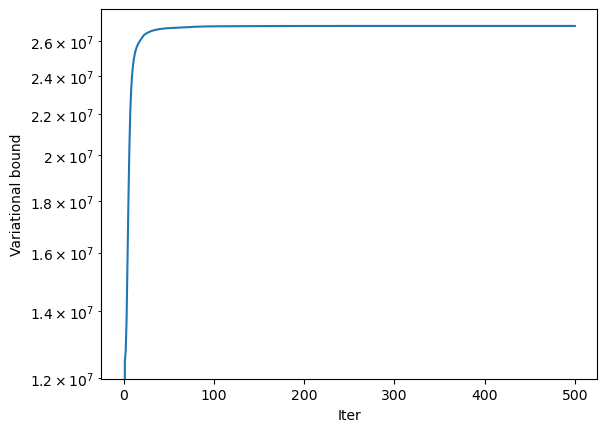

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 24, 3]), device='cuda',
     n_components=50)

In [5]:
n_components = 50
max_iter = 500
tol = 1e-8
verbose = False

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with last mode completely masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-5555518242.219843, 12566977.656622075, 12791267.237043817, 13541026.624177616, 15520845.13273298, 18171386.12094778, 20581406.41526494, 22158461.33231243, 23138247.745974295, 23847503.547144547, 24395741.009140916, 24838554.69216702, 25193602.044386018, 25472366.27212721, 25695753.29687654, 25868197.494559005, 25999155.015296422, 26103276.788020343, 26188633.2613739, 26260267.458546776, 26321863.67787769, 26375168.31488309, 26420833.579697177, 26460051.22562759, 26494399.593190785, 26524855.898331884, 26551643.212740757, 26574903.435386054, 26595166.11094041, 26613096.863282457, 26629167.479619905, 26643832.236519825, 26657348.24779544, 26669754.572787013, 26681244.46007477, 26691859.109016538, 26701723.047246467, 26710940.773391422, 26719615.35132777, 26727846.961633213, 26735668.48936449, 26743147.469529424, 26750341.20608869, 26757294.418804206, 26764055.947839446, 26770671.43371023, 267

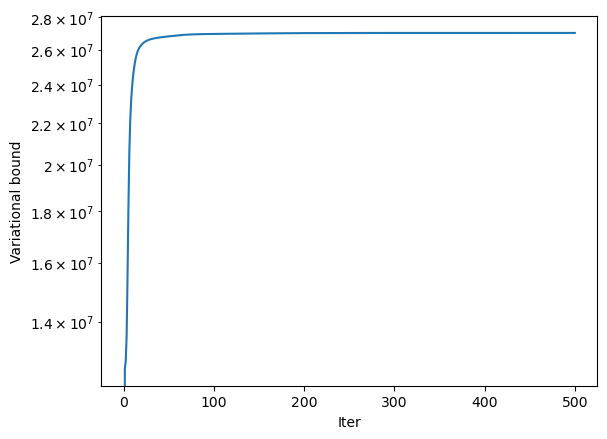

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 24, 3]), device='cuda',
     n_components=50)

In [6]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, :] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with the 1st and 3rd indices masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-5678550000.803636, 12948505.798518902, 13538534.926684083, 14502803.956449969, 16550118.324709082, 18952635.389299694, 21209965.7156973, 22974798.911199037, 24195526.610861927, 25027100.44458823, 25592822.239911582, 25997775.67039959, 26298354.19665701, 26537851.750684693, 26748498.738253843, 26928940.2086215, 27067475.232810482, 27177596.24802043, 27267607.169619817, 27342785.94683129, 27407710.05008419, 27465823.01124436, 27519546.21955529, 27570781.422772232, 27621210.440879457, 27670572.315635804, 27716239.804524954, 27756581.764098074, 27791891.176840723, 27823200.36253688, 27851402.372232255, 27876927.12197156, 27900153.434311733, 27921203.914840855, 27940214.850756586, 27957430.789053917, 27973124.33138193, 27987474.628239967, 28000640.979958076, 28012787.876412436, 28024063.570041765, 28034521.471213616, 28044195.949228965, 28053180.269298077, 28061531.187315986, 28069327.33226028, 

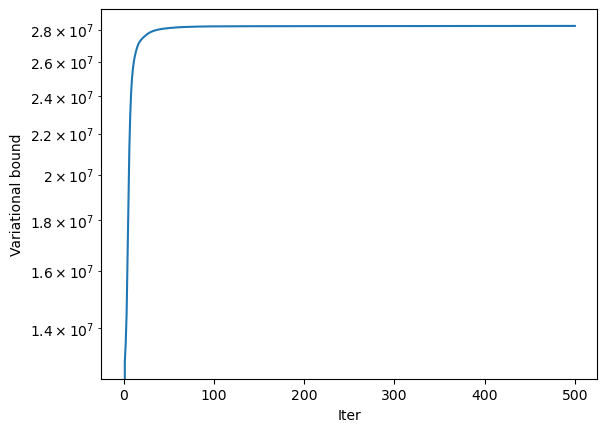

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 24, 3]), device='cuda',
     n_components=50)

In [7]:
mask = np.ones(data.shape)
# april is set to missing
mask[:, :, :, 3, [0, 2]] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with only diagonals masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-5879539871.12143, 13181407.736941373, 13435460.82863588, 14393648.81780658, 16317066.837996777, 18869766.847954348, 21417411.151640866, 23320532.31883192, 24508769.360988665, 25266647.261910707, 25816012.270442564, 26237418.26773756, 26564209.97215429, 26832319.99706904, 27037168.964703247, 27187404.90660143, 27305255.44791575, 27401023.437867306, 27479694.0672031, 27545457.47317817, 27601921.52104883, 27651763.182349518, 27696605.728461076, 27737541.715693053, 27775036.930898633, 27809258.036568716, 27840346.472184934, 27868472.948961485, 27893882.805170923, 27916884.981124215, 27937784.87485008, 27956840.354029626, 27974094.20831144, 27989531.534152716, 28003336.9784594, 28015873.981398173, 28027521.775215764, 28038599.902520705, 28049222.729509827, 28059203.44602324, 28068529.715850763, 28077248.842605297, 28085412.180100348, 28093010.366791688, 28100106.345081538, 28106771.270632114, 28

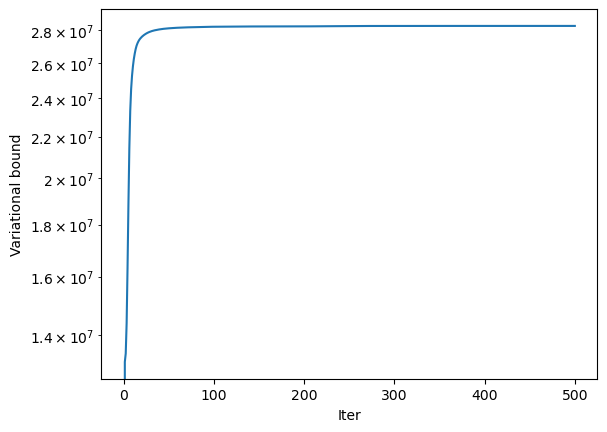

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 24, 3]), device='cuda',
     n_components=50)

In [8]:
mask = np.ones(data.shape)

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# No mask

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-5784169048.471269, 18442754.547394022, 18874172.973712843, 20588760.804029707, 24298872.51789427, 28741957.735065684, 32351088.24777435, 34661590.90799737, 36271664.26120132, 37405884.637242116, 38139249.3572538, 38624650.08444412, 38966296.69410456, 39216361.48959712, 39410920.64737592, 39570568.99273935, 39707342.40573783, 39827663.422724426, 39931000.2256529, 40018166.831217036, 40090413.63005141, 40146799.40352651, 40191181.42289045, 40228912.914815, 40263977.14539958, 40298510.46465327, 40328212.660090506, 40350639.298678115, 40367789.706771195, 40381835.9227796, 40393932.92693614, 40404672.146516025, 40414474.976553686, 40423648.087368585, 40432323.36671969, 40440260.32090257, 40447319.71375753, 40453648.412339024, 40459423.459798224, 40464775.176997624, 40469795.45567256, 40474565.002366945, 40479151.33788844, 40483646.997982144, 40488227.84343948, 40493110.28406692, 40498054.6176209

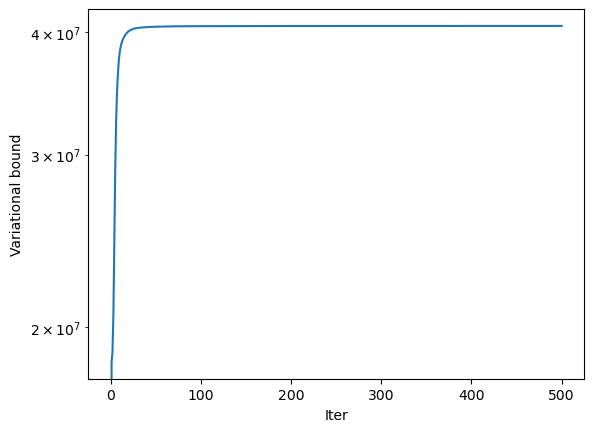

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 24, 3]), device='cuda',
     n_components=50)

In [9]:
BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = None, max_iter = max_iter, verbose=verbose, tol=tol)

In [10]:
with torch.no_grad():
    # torch.cuda.synchronize()
    b1 = BPTF_model._elbo(data, mask)
    torch.cuda.synchronize()
    b2 = BPTF_model._elbo(data, mask)
print((b2 - b1) * 1e8)               # absolute change in “ULPs”

tensor(0., device='cuda:0')
